### **项目 多元线性回归预测啤酒评分**

#### 分析目标

本项目的主要目标如下：

1. **数据清洗与探索**：对原始数据进行质量评估，处理缺失值、重复值和异常值，确保数据干净可用。
2. **可视化与假设检验**：通过图表探索各特征与总体评分的关系，并运用假设检验（如 t 检验）验证高酒精度与低酒精度啤酒在评分上是否存在显著差异。
3. **建立预测模型**：利用多元线性回归，以香气、外观、口感、口味、酒精度作为自变量，构建能够预测啤酒总体评分的模型。
4. **模型评估与优化**：通过拆分训练集和测试集，评估模型的拟合效果和泛化能力（R²、RMSE、MAE、残差分析），确保模型可靠。
5. **业务洞察**：根据模型系数，分析哪些因素对啤酒评分影响最大，为品酒或产品改进提供数据支持。

`news.csv`每列的含义如下

brewery_id:啤酒厂编号

brewery_name：啤酒厂名称

review_time：评审时间

review_overall：总体评分

review_aroma：香气评分

review_appearance：外观评分

review_profilename：评价用户名

beer_style：啤酒风格

review_palate：口感评分

review_taste：口味评分

beer_name：啤酒名称

beer_abv：酒精度

beer_beerid：啤酒编号

数据来源于kaggle，包含158661条玩家数据

### **读取数据**

In [1]:
import numpy as np
import pandas as pd

In [2]:
original_data = pd.read_csv('news.csv')
original_data

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,13307,Mikkeller ApS,1317606533,4.0,4.5,4.5,Ghenna,American Barleywine,3.5,3.5,Big Worst,18.5,56831
1,126,Pete's Brewing Company,1195281294,2.5,3.0,3.5,hwwty4,Cream Ale,3.0,2.5,Pete's Wicked Wanderlust Cream Ale,5.6,19950
2,203,Greene King / Morland Brewery,1224109943,4.0,3.5,4.0,dsa7783,English Pale Ale,3.5,3.5,Abbot Ale,5.0,910
3,167,Brewery Lobkowicz,1070489226,4.5,4.0,3.5,TastyTaste,Czech Pilsener,4.0,4.5,Lobkowicz Knight,4.8,444
4,664,Wells & Young's Ltd,1172208746,5.0,4.0,5.0,BadRockBeer,Milk / Sweet Stout,5.0,5.0,Young's Double Chocolate Stout,5.2,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158656,156,Tommyknocker Brewery,1317043835,4.0,3.0,4.0,tigg924,American Amber / Red Lager,3.0,3.5,Ornery Amber,5.4,2294
158657,345,Victory Brewing Company,1049654478,4.5,3.5,3.0,mzwolinski,Märzen / Oktoberfest,4.0,4.0,Festbier,5.6,1017
158658,553,Bierbrouwerij Sint Christoffel B.V,1249955716,4.0,2.5,3.5,Mit,Dubbel,3.5,3.5,Christoffel Dubbel,6.4,48275
158659,10099,Dogfish Head Brewery,1251078161,2.5,3.5,4.5,crossovert,American Double / Imperial IPA,3.5,3.5,120 Minute IPA,18.0,9086


### **评估和清洗数据**

In [3]:
cleaned_data = original_data.copy()
cleaned_data

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,13307,Mikkeller ApS,1317606533,4.0,4.5,4.5,Ghenna,American Barleywine,3.5,3.5,Big Worst,18.5,56831
1,126,Pete's Brewing Company,1195281294,2.5,3.0,3.5,hwwty4,Cream Ale,3.0,2.5,Pete's Wicked Wanderlust Cream Ale,5.6,19950
2,203,Greene King / Morland Brewery,1224109943,4.0,3.5,4.0,dsa7783,English Pale Ale,3.5,3.5,Abbot Ale,5.0,910
3,167,Brewery Lobkowicz,1070489226,4.5,4.0,3.5,TastyTaste,Czech Pilsener,4.0,4.5,Lobkowicz Knight,4.8,444
4,664,Wells & Young's Ltd,1172208746,5.0,4.0,5.0,BadRockBeer,Milk / Sweet Stout,5.0,5.0,Young's Double Chocolate Stout,5.2,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158656,156,Tommyknocker Brewery,1317043835,4.0,3.0,4.0,tigg924,American Amber / Red Lager,3.0,3.5,Ornery Amber,5.4,2294
158657,345,Victory Brewing Company,1049654478,4.5,3.5,3.0,mzwolinski,Märzen / Oktoberfest,4.0,4.0,Festbier,5.6,1017
158658,553,Bierbrouwerij Sint Christoffel B.V,1249955716,4.0,2.5,3.5,Mit,Dubbel,3.5,3.5,Christoffel Dubbel,6.4,48275
158659,10099,Dogfish Head Brewery,1251078161,2.5,3.5,4.5,crossovert,American Double / Imperial IPA,3.5,3.5,120 Minute IPA,18.0,9086


#### **整齐度**

In [4]:
cleaned_data.head(10)

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,13307,Mikkeller ApS,1317606533,4.0,4.5,4.5,Ghenna,American Barleywine,3.5,3.5,Big Worst,18.50,56831
1,126,Pete's Brewing Company,1195281294,2.5,3.0,3.5,hwwty4,Cream Ale,3.0,2.5,Pete's Wicked Wanderlust Cream Ale,5.60,19950
2,203,Greene King / Morland Brewery,1224109943,4.0,3.5,4.0,dsa7783,English Pale Ale,3.5,3.5,Abbot Ale,5.00,910
3,167,Brewery Lobkowicz,1070489226,4.5,4.0,3.5,TastyTaste,Czech Pilsener,4.0,4.5,Lobkowicz Knight,4.80,444
4,664,Wells & Young's Ltd,1172208746,5.0,4.0,5.0,BadRockBeer,Milk / Sweet Stout,5.0,5.0,Young's Double Chocolate Stout,5.20,73
5,30,Avery Brewing Company,1161643310,3.5,4.5,4.5,AaronHomoya,Quadrupel (Quad),4.0,4.0,The Reverend,10.00,2014
6,22,Unibroue,1215184654,3.0,2.5,3.0,cvstrickland,Fruit / Vegetable Beer,3.0,3.0,Éphémère (Apple),5.50,3523
7,224,St. Pauli Brauerei C.L. Wilh. Brandt Gmbh & Co.,1276036822,2.0,2.5,3.0,PapaGemutlich,Munich Dunkel Lager,3.0,2.5,St. Pauli Girl Special Dark,4.80,698
8,10099,Dogfish Head Brewery,1192893550,3.5,4.5,4.0,jaxon53,American Barleywine,4.0,4.0,Olde School Barleywine,15.04,6533
9,9897,Jolly Pumpkin Artisan Ales,1288755942,4.0,4.0,4.0,Mora2000,Pumpkin Ale,4.0,4.0,La Parcela,6.00,45723


In [5]:
cleaned_data.tail(10)

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
158651,147,Stone Brewing Co.,1095904482,3.0,3.5,3.0,HappyHourHero,American Brown Ale,3.5,3.5,Stone 8th Anniversary Ale,7.8,19186
158652,287,"Bell's Brewery, Inc.",1143403182,4.0,3.5,3.5,ski271,American Stout,3.5,4.0,Bell's Cherry Stout,7.0,2511
158653,751,Big Sky Brewing Company,1304637842,4.0,4.0,4.5,welldigger888,American Brown Ale,4.5,4.0,Moose Drool Brown Ale,5.1,2296
158654,345,Victory Brewing Company,1310576728,4.0,4.0,3.0,DeltaGolfSierra,German Pilsener,4.5,4.0,Prima Pils,5.3,1010
158655,147,Stone Brewing Co.,1056141590,5.0,5.0,4.5,WVbeergeek,Russian Imperial Stout,4.0,4.5,Stone Imperial Russian Stout,10.5,1160
158656,156,Tommyknocker Brewery,1317043835,4.0,3.0,4.0,tigg924,American Amber / Red Lager,3.0,3.5,Ornery Amber,5.4,2294
158657,345,Victory Brewing Company,1049654478,4.5,3.5,3.0,mzwolinski,Märzen / Oktoberfest,4.0,4.0,Festbier,5.6,1017
158658,553,Bierbrouwerij Sint Christoffel B.V,1249955716,4.0,2.5,3.5,Mit,Dubbel,3.5,3.5,Christoffel Dubbel,6.4,48275
158659,10099,Dogfish Head Brewery,1251078161,2.5,3.5,4.5,crossovert,American Double / Imperial IPA,3.5,3.5,120 Minute IPA,18.0,9086
158660,192,New Belgium Brewing,1302327060,4.0,4.5,4.0,Lessurluck,American Wild Ale,4.0,4.5,Lips Of Faith - Le Terroir,7.5,26541


In [6]:
cleaned_data.sample(10)

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
123811,99,Matt Brewing Company,1238036278,3.5,3.5,4.5,DoctorDog,American IPA,3.5,3.5,Saranac India Pale Ale,5.8,1464
67918,637,Brasserie Dupont sprl,1244858411,5.0,4.0,4.5,TurdFurgison,Saison / Farmhouse Ale,4.0,3.5,Avril,3.5,42772
113420,141,Smuttynose Brewing Company,1231902358,5.0,3.5,3.5,lpayette,Wheatwine,4.5,4.5,Smuttynose Wheat Wine (Big Beer Series),10.7,21804
146449,435,Minhas Craft Brewery,1306904099,2.5,2.5,3.5,TMoney2591,American Amber / Red Ale,2.5,2.0,Berghoff Rock River Red Ale,NaN,45439
112206,14400,Ninkasi Brewing Company,1272932697,4.5,3.5,3.5,SpeedwayJim,American Double / Imperial IPA,4.5,3.0,Tricerahops Double IPA,8.8,37966
101474,1805,Rock Art Brewery,1203180448,4.0,4.0,4.0,tempest,English Barleywine,3.5,4.0,Ridge Runner,7.5,5336
143726,72,Weisses Bräuhaus G. Schneider & Sohn GmbH,1280246653,4.0,4.5,4.0,claspada,Weizenbock,4.0,4.0,Schneider Aventinus,8.2,224
142738,10153,Pisgah Brewing Co.,1283552683,4.0,4.5,4.0,Metalmonk,English Barleywine,4.0,4.5,Hellbender Barleywine,9.8,28941
120769,1872,McKenzie Brew House,1324324051,4.0,3.0,3.5,cpetrone84,Saison / Farmhouse Ale,3.5,3.5,Houblonette,4.7,70213
26390,75,Grupo Modelo S.A. de C.V.,1157989215,2.5,3.5,3.0,tesguino,Light Lager,3.5,3.0,Modelo Light,4.0,11554


从头部的10行数据、结尾的10行数据以及随机抽样的10行数据来看，数据符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”，因此不存在结构性问题。

#### **干净度**

In [7]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 158661 entries, 0 to 158660
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brewery_id          158661 non-null  int64  
 1   brewery_name        158659 non-null  str    
 2   review_time         158661 non-null  int64  
 3   review_overall      158661 non-null  float64
 4   review_aroma        158661 non-null  float64
 5   review_appearance   158661 non-null  float64
 6   review_profilename  158625 non-null  str    
 7   beer_style          158661 non-null  str    
 8   review_palate       158661 non-null  float64
 9   review_taste        158661 non-null  float64
 10  beer_name           158661 non-null  str    
 11  beer_abv            151802 non-null  float64
 12  beer_beerid         158661 non-null  int64  
dtypes: float64(6), int64(3), str(4)
memory usage: 15.7 MB


从结果看来，该数据集一共有158661行数据，其中`brewery_name`列，`review_profilename`列，`beer_abv`列存在缺失值，`brewery_id`、`beer_beerid`的数据类型应改为str,`review_time`列的数据类型也不对，但此列对我们本次数据分析的目的没有作用，把这列删除

In [8]:
cleaned_data['brewery_id'] = cleaned_data['brewery_id'].astype('str')

In [9]:
cleaned_data['beer_beerid'] = cleaned_data['beer_beerid'].astype('str')

检查一下修改后的结果

In [10]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 158661 entries, 0 to 158660
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brewery_id          158661 non-null  str    
 1   brewery_name        158659 non-null  str    
 2   review_time         158661 non-null  int64  
 3   review_overall      158661 non-null  float64
 4   review_aroma        158661 non-null  float64
 5   review_appearance   158661 non-null  float64
 6   review_profilename  158625 non-null  str    
 7   beer_style          158661 non-null  str    
 8   review_palate       158661 non-null  float64
 9   review_taste        158661 non-null  float64
 10  beer_name           158661 non-null  str    
 11  beer_abv            151802 non-null  float64
 12  beer_beerid         158661 non-null  str    
dtypes: float64(6), int64(1), str(6)
memory usage: 15.7 MB


删除`review_time`列

In [11]:
cleaned_data = cleaned_data.drop('review_time',axis = 1)
cleaned_data

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,13307,Mikkeller ApS,4.0,4.5,4.5,Ghenna,American Barleywine,3.5,3.5,Big Worst,18.5,56831
1,126,Pete's Brewing Company,2.5,3.0,3.5,hwwty4,Cream Ale,3.0,2.5,Pete's Wicked Wanderlust Cream Ale,5.6,19950
2,203,Greene King / Morland Brewery,4.0,3.5,4.0,dsa7783,English Pale Ale,3.5,3.5,Abbot Ale,5.0,910
3,167,Brewery Lobkowicz,4.5,4.0,3.5,TastyTaste,Czech Pilsener,4.0,4.5,Lobkowicz Knight,4.8,444
4,664,Wells & Young's Ltd,5.0,4.0,5.0,BadRockBeer,Milk / Sweet Stout,5.0,5.0,Young's Double Chocolate Stout,5.2,73
...,...,...,...,...,...,...,...,...,...,...,...,...
158656,156,Tommyknocker Brewery,4.0,3.0,4.0,tigg924,American Amber / Red Lager,3.0,3.5,Ornery Amber,5.4,2294
158657,345,Victory Brewing Company,4.5,3.5,3.0,mzwolinski,Märzen / Oktoberfest,4.0,4.0,Festbier,5.6,1017
158658,553,Bierbrouwerij Sint Christoffel B.V,4.0,2.5,3.5,Mit,Dubbel,3.5,3.5,Christoffel Dubbel,6.4,48275
158659,10099,Dogfish Head Brewery,2.5,3.5,4.5,crossovert,American Double / Imperial IPA,3.5,3.5,120 Minute IPA,18.0,9086


#### **缺失值**

先前发现brewery_name列，review_profilename列，beer_abv列存在缺失值，现在处理这些缺失值

In [12]:
cleaned_data.query('brewery_name.isna()')

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
78672,1193,NaN,3.5,3.5,4.0,dqrull,Keller Bier / Zwickel Bier,4.0,4.0,Engel Keller Dunkel WRONG BREWERY SEE CRAILSH...,5.3,63324
119545,27,NaN,5.0,4.5,4.0,Docer,American Stout,4.5,4.5,Caboose Oatmeal Stout,7.0,75137


In [13]:
cleaned_data.query('review_profilename.isna()')

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
745,259,Brouwerij St. Bernardus NV,4.5,5.0,4.0,NaN,Tripel,5.0,4.5,St. Bernardus Tripel,8.00,722
16334,610,Bear Republic Brewing Co.,3.5,3.0,3.5,NaN,Rye Beer,4.0,3.5,Hop Rod Rye,8.00,3158
18381,2743,Green Flash Brewing Co.,4.5,4.0,4.0,NaN,American Double / Imperial IPA,4.0,4.5,Green Flash Imperial India Pale Ale,9.40,34085
23767,1417,Black Sheep Brewery PLC,3.0,3.0,4.0,NaN,English Brown Ale,3.5,3.0,Riggwelter Yorkshire Ale,5.70,3939
28792,28,Anchor Brewing Company,4.0,4.0,4.5,NaN,Winter Warmer,4.0,4.5,Our Special Ale 2008 (Anchor Christmas Ale),5.50,45537
32014,1656,South Australia Brewing Co.,3.0,2.5,3.0,NaN,American Adjunct Lager,3.0,3.0,Southwark Premium,5.20,5342
35190,345,Victory Brewing Company,5.0,5.0,4.5,NaN,American Double / Imperial IPA,4.5,5.0,Hop Wallop,8.50,14916
39154,470,Abbaye de Leffe S.A.,3.5,4.0,3.0,NaN,Belgian Pale Ale,3.0,3.0,Leffe Blonde,6.60,2137
39909,470,Abbaye de Leffe S.A.,3.5,3.0,4.0,NaN,Belgian Strong Dark Ale,3.0,2.5,Leffe Radieuse,8.20,2138
40437,10099,Dogfish Head Brewery,3.0,4.0,3.5,NaN,American Brown Ale,3.5,4.0,Indian Brown Ale,7.20,1161


In [14]:
cleaned_data.query('beer_abv.isna()')

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
28,4338,C.B. & Potts Restaurant & Brewery,2.5,3.0,3.0,rowew,American Amber / Red Ale,3.0,3.0,Big Horn Buttface Amber Ale,NaN,25912
37,1874,Pizzeria Uno Chicago Grill & Brewery,3.5,3.0,3.0,Dogbrick,Hefeweizen,3.0,2.5,Hefeweizen,NaN,12429
55,2854,Flensburger Brauerei GmbH Und Co. KG,4.0,4.5,4.0,Cadyfatcat,Hefeweizen,3.5,3.5,Flensburger Weizen,NaN,6712
82,341,Columbus Brewing Company,4.0,3.5,4.0,Ahhdball,American Pale Ale (APA),3.5,3.5,Columbus Pale Ale,NaN,3700
84,1916,Kettle House Brewing Co.,4.5,4.0,4.0,beernut7,American Pale Ale (APA),4.0,4.5,Ginseng Pale Ale,NaN,5589
...,...,...,...,...,...,...,...,...,...,...,...,...
158563,684,Fish Brewing Company / Fishbowl Brewpub,3.0,3.0,3.5,RedDiamond,German Pilsener,2.5,3.0,Reister Pilsner,NaN,54202
158579,1111,Martha's Vineyard Ales,4.5,4.5,4.5,TheLongBeachBum,Foreign / Export Stout,5.0,5.0,Martha's Vineyard Extra Stout,NaN,3266
158644,5408,Herkimer Pub & Brewery,3.5,3.0,4.0,tempest,Altbier,3.5,3.5,Alt,NaN,21231
158649,7776,Brauerei Westheim GmbH,3.0,3.0,3.5,allengarvin,Märzen / Oktoberfest,3.5,3.5,Westheimer Oktoberfest,NaN,20547


啤酒工厂名称(brewery_name)对预测啤酒评分没有影响，且只有2条缺失，可直接删除这2行；评价用户名(review_profilename)对预测啤酒评分也没有影响，并且它不是数值类型，可不做处理；啤酒的酒精度(beer_abv)会影响啤酒评分结果，并且有6859条缺失，数量比较庞大，因此不可删除，我们用平均酒精度去充填缺失值

In [15]:
cleaned_data = cleaned_data.drop(index=[78672, 119545]) #删除啤酒工厂名称缺失的2行

验证是否还有啤酒工厂名称空缺的行

In [16]:
cleaned_data.query('brewery_name.isna()')

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid


In [17]:
mean_abv = cleaned_data['beer_abv'].mean() #计算酒精度的平均值
cleaned_data['beer_abv'] = cleaned_data['beer_abv'].fillna(mean_abv) #用平均值去替换酒精度为 NaN 的值

验证是否还有 NaN 值

In [18]:
print(cleaned_data['beer_abv'].isna().sum())

0


#### **重复数据**

数据量比较庞大，需要检查一下是否有重复行

In [19]:
dup = cleaned_data.duplicated().sum()
dup

np.int64(11)

有11行重复，接下来删除这些重复的行

In [20]:
cleaned_data = cleaned_data.drop_duplicates()

删除完成，再次检查重复行数量

In [21]:
dup = cleaned_data.duplicated().sum()
dup

np.int64(0)

#### **不一致数据**

此数据集中没有分类数据，因此无需处理不一致数据

#### **无效或错误数据**

In [22]:
cleaned_data.describe()

,review_overall,review_aroma,review_appearance,review_palate,review_taste,beer_abv
count,158648.000000,158648.000000,158648.000000,158648.000000,158648.000000,158648.000000
mean,3.812352,3.734195,3.840231,3.741913,3.789093,7.037713
std,0.719497,0.695315,0.615717,0.681284,0.731923,2.272188
min,0.000000,1.000000,0.000000,1.000000,1.000000,0.050000
25%,3.500000,3.500000,3.500000,3.500000,3.500000,5.300000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,6.600000
75%,4.500000,4.000000,4.000000,4.000000,4.500000,8.400000
max,5.000000,5.000000,5.000000,5.000000,5.000000,41.000000


从输出结果看来，`review_overall` 和 `review_appearance` 的最小值为 0，而其他子评分最小为 1，这可能表示缺失或无效评分，查找出这些话检查一下

In [23]:
cleaned_data.query('review_overall == 0')

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
22707,1413,Desert Edge Brewery,0.0,3.0,0.0,beernut7,American Pale Ale (APA),2.0,2.0,Utah Pale Ale,4.0,3810


In [24]:
cleaned_data.query('review_appearance == 0')

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
22707,1413,Desert Edge Brewery,0.0,3.0,0.0,beernut7,American Pale Ale (APA),2.0,2.0,Utah Pale Ale,4.0,3810


从查找结果发现，凡`review_overall`为0，`review_appearance也`为0,这也就意味着，外观一旦不良（0分），综合评分一定为0，合理

此外，啤酒的酒精度(abv)最小值是0.050000，平均值7.037713，但最大值41.000000，比较极端，也把这列查找出来看一看

In [25]:
cleaned_data.query('beer_abv == 41')

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
11397,16315,BrewDog,4.0,4.5,4.0,northyorksammy,American Double / Imperial IPA,4.0,4.0,Sink The Bismarck!,41.0,57015
41892,16315,BrewDog,2.5,4.0,3.5,cyrock1,American Double / Imperial IPA,2.5,3.5,Sink The Bismarck!,41.0,57015
83735,16315,BrewDog,4.5,5.0,4.5,SShelly,American Double / Imperial IPA,4.0,4.5,Sink The Bismarck!,41.0,57015
91792,16315,BrewDog,5.0,5.0,5.0,ATvics,American Double / Imperial IPA,5.0,5.0,Sink The Bismarck!,41.0,57015
104766,16315,BrewDog,4.0,4.0,5.0,utah44,American Double / Imperial IPA,4.5,4.0,Sink The Bismarck!,41.0,57015
123783,16315,BrewDog,2.0,4.0,4.5,BearsOnAcid,American Double / Imperial IPA,4.0,4.5,Sink The Bismarck!,41.0,57015
150383,16315,BrewDog,5.0,5.0,4.5,hopheadtony1,American Double / Imperial IPA,4.5,5.0,Sink The Bismarck!,41.0,57015
151985,16315,BrewDog,3.5,4.5,3.5,cdkrenz,American Double / Imperial IPA,2.0,4.0,Sink The Bismarck!,41.0,57015
153075,16315,BrewDog,4.0,4.0,4.5,LtCracker20,American Double / Imperial IPA,4.0,3.5,Sink The Bismarck!,41.0,57015


9条结果显示，不论是`brewery_id`、`brewery_name`、`beer_style`、`beer_name`、`beer_beerid`，都是一样的，由此可以确认这是同一工厂的同品相啤酒，酒精度全都是41就合理，但仍需确认这种啤酒的酒精度是否真的能达到41,；通过查询相关资料，确实查到了同样的啤酒，酒精度能达到41，那么酒精度41这项也合理；

### **可视化探索与假设检验**

##### 先引入做t检验、z检验所需要的模块¶

In [26]:
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import ztest

##### 再引入绘图所需要的模块¶

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

#### **高酒精度啤酒评分与低酒精度啤酒评分的差异¶**

##### **将高酒精度啤酒与低酒精度啤酒分开（以6为界限）**

In [28]:
H_abv_beer = cleaned_data.query("beer_abv >= 6")
H_abv_beer

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,13307,Mikkeller ApS,4.0,4.5,4.5,Ghenna,American Barleywine,3.5,3.5,Big Worst,18.50,56831
5,30,Avery Brewing Company,3.5,4.5,4.5,AaronHomoya,Quadrupel (Quad),4.0,4.0,The Reverend,10.00,2014
8,10099,Dogfish Head Brewery,3.5,4.5,4.0,jaxon53,American Barleywine,4.0,4.0,Olde School Barleywine,15.04,6533
9,9897,Jolly Pumpkin Artisan Ales,4.0,4.0,4.0,Mora2000,Pumpkin Ale,4.0,4.0,La Parcela,6.00,45723
15,29,Anheuser-Busch,4.0,4.0,3.5,TheFightfan1,Winter Warmer,4.5,4.0,Winter's Bourbon Cask Ale,6.00,27354
...,...,...,...,...,...,...,...,...,...,...,...,...
158652,287,"Bell's Brewery, Inc.",4.0,3.5,3.5,ski271,American Stout,3.5,4.0,Bell's Cherry Stout,7.00,2511
158655,147,Stone Brewing Co.,5.0,5.0,4.5,WVbeergeek,Russian Imperial Stout,4.0,4.5,Stone Imperial Russian Stout,10.50,1160
158658,553,Bierbrouwerij Sint Christoffel B.V,4.0,2.5,3.5,Mit,Dubbel,3.5,3.5,Christoffel Dubbel,6.40,48275
158659,10099,Dogfish Head Brewery,2.5,3.5,4.5,crossovert,American Double / Imperial IPA,3.5,3.5,120 Minute IPA,18.00,9086


In [29]:
len(H_abv_beer)

96927

In [30]:
L_abv_beer = cleaned_data.query("beer_abv < 6")
L_abv_beer

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
1,126,Pete's Brewing Company,2.5,3.0,3.5,hwwty4,Cream Ale,3.0,2.5,Pete's Wicked Wanderlust Cream Ale,5.6,19950
2,203,Greene King / Morland Brewery,4.0,3.5,4.0,dsa7783,English Pale Ale,3.5,3.5,Abbot Ale,5.0,910
3,167,Brewery Lobkowicz,4.5,4.0,3.5,TastyTaste,Czech Pilsener,4.0,4.5,Lobkowicz Knight,4.8,444
4,664,Wells & Young's Ltd,5.0,4.0,5.0,BadRockBeer,Milk / Sweet Stout,5.0,5.0,Young's Double Chocolate Stout,5.2,73
6,22,Unibroue,3.0,2.5,3.0,cvstrickland,Fruit / Vegetable Beer,3.0,3.0,Éphémère (Apple),5.5,3523
...,...,...,...,...,...,...,...,...,...,...,...,...
158647,29,Anheuser-Busch,2.5,1.5,3.0,optimator13,Light Lager,3.0,2.0,Budweiser Select 55,2.4,52480
158653,751,Big Sky Brewing Company,4.0,4.0,4.5,welldigger888,American Brown Ale,4.5,4.0,Moose Drool Brown Ale,5.1,2296
158654,345,Victory Brewing Company,4.0,4.0,3.0,DeltaGolfSierra,German Pilsener,4.5,4.0,Prima Pils,5.3,1010
158656,156,Tommyknocker Brewery,4.0,3.0,4.0,tigg924,American Amber / Red Lager,3.0,3.5,Ornery Amber,5.4,2294


In [31]:
len(L_abv_beer)

61721

##### **设置色盘中文字体显示**

In [32]:
sns.set_palette("pastel")
plt.rcParams['font.sans-serif'] = ['SimHei']

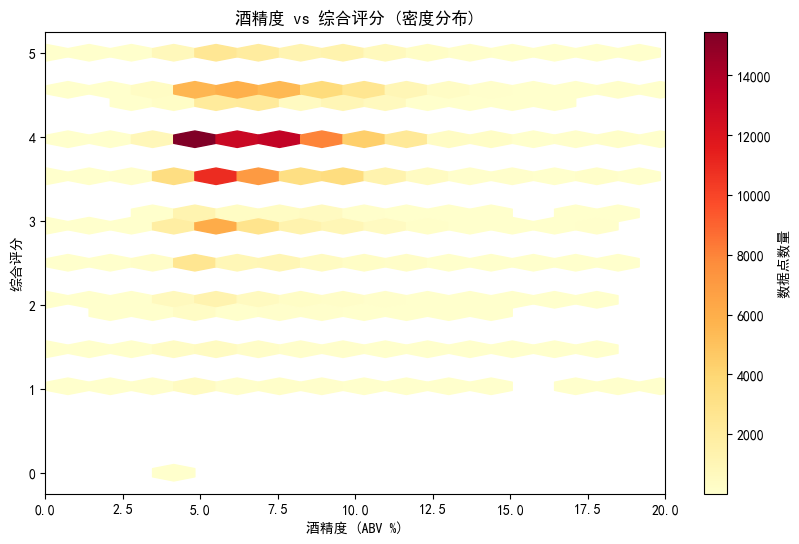

In [33]:
plt.figure(figsize=(10, 6)) #设置画布大小
plt.hexbin(cleaned_data['beer_abv'], cleaned_data['review_overall'], gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='数据点数量')
plt.xlabel('酒精度 (ABV %)')
plt.ylabel('综合评分')
plt.title('酒精度 vs 综合评分 (密度分布)')
plt.xlim(0, 20)  # 酒精度超过20%的占比极少，截断可放大主体趋势
plt.show()

图片显示，酒精度从0~20，每个区间都有高评分啤酒（评分为5），由此可以猜测，高酒精度啤酒与低酒精度啤酒在总体评分上无显著差异

#### **建立假设**

原假设$H_0$：高酒精度啤酒与低酒精度啤酒在总体评分上无显著性差异

备择假设$H_1$：高酒精度啤酒与低酒精度啤酒在总体评分上有显著差异

#### **确认检验是单尾还是双尾**

我们只想确定高酒精度啤酒与低酒精度啤酒在总体评分上存不存在显著差异，因此是双尾检验

#### **确定显著水平**

选择0.05作为显著水平

#### **计算t值和p值**

In [34]:
t_stat, p_value = ttest_ind(H_abv_beer["review_overall"], L_abv_beer["review_overall"])
print(f"t值：{t_stat}")
print(f"p值：{p_value}")

t值：63.48685739864998
p值：0.0


#### **结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明高酒精度啤酒与低酒精度啤酒在总体评分上有显著差异，这也证明了我们先前的猜测是错误的

#### **香气评分与总体评分的关系**

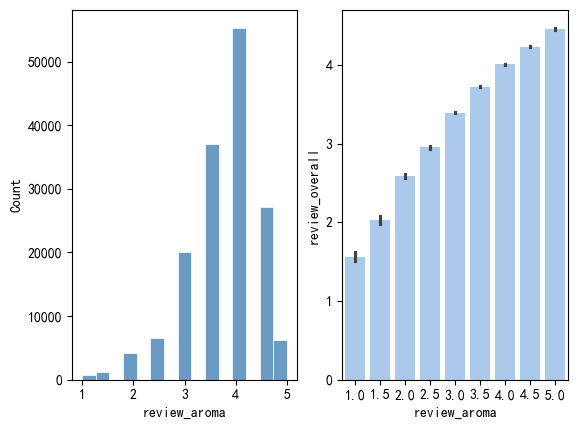

In [35]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_data, x='review_aroma', bins = 15,color='steelblue',edgecolor='white',linewidth=0.5,alpha=0.8,stat='count',ax=axes[0])
sns.barplot(cleaned_data, x='review_aroma', y='review_overall', ax=axes[1])
plt.show()

香气评分在4分的数量最多，且香气评分越高的啤酒，总体评分也越高

#### **外观评分与总体评分的关系**

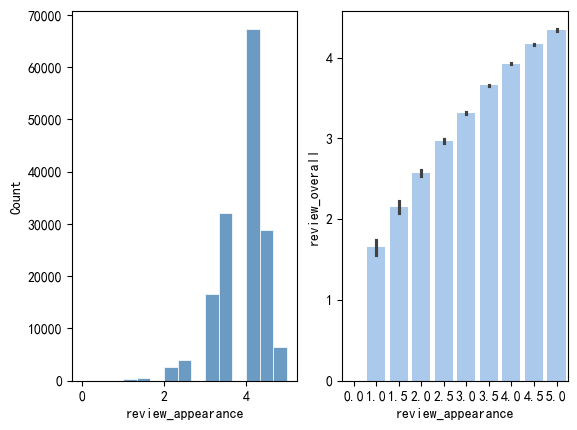

In [36]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_data, x='review_appearance', bins = 15,color='steelblue',edgecolor='white',linewidth=0.5,alpha=0.8,stat='count',ax=axes[0])
sns.barplot(cleaned_data, x='review_appearance', y='review_overall', ax=axes[1])
plt.show()

#### **口感评分与总体评分的关系**

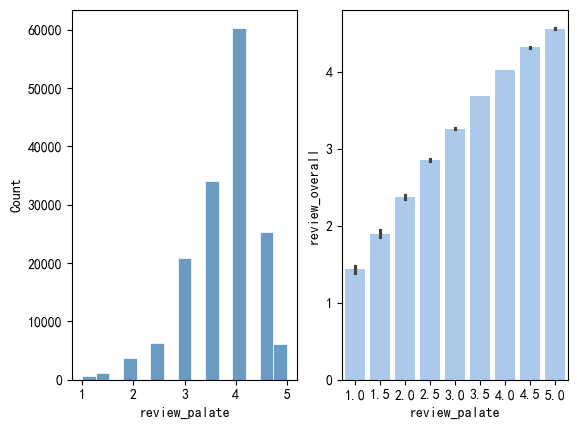

In [37]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_data, x='review_palate', bins = 15,color='steelblue',edgecolor='white',linewidth=0.5,alpha=0.8,stat='count',ax=axes[0])
sns.barplot(cleaned_data, x='review_palate', y='review_overall', ax=axes[1])
plt.show()

#### **口味评分与总体评分的关系**

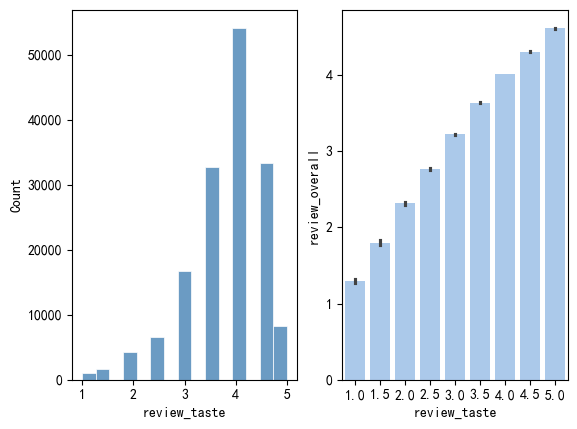

In [38]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_data, x='review_taste', bins = 15,color='steelblue',edgecolor='white',linewidth=0.5,alpha=0.8,stat='count',ax=axes[0])
sns.barplot(cleaned_data, x='review_taste', y='review_overall', ax=axes[1])
plt.show()

#### **结论**

外观评分与总体评分的关系、口感评分与总体评分的关系、口味评分与总体评分的关系与香气评分与总体评分的关系整体类似，这也符合常理

### **建立预测模型**

引入做逻辑回归所需的模块

In [39]:
import statsmodels.api as sm

为了避免清洗好的数据丢失，创建一个新的DataFrame作为建立线性回归模型所使用的数据 LR_data

In [40]:
LR_data = cleaned_data.copy()
LR_data

,brewery_id,brewery_name,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,13307,Mikkeller ApS,4.0,4.5,4.5,Ghenna,American Barleywine,3.5,3.5,Big Worst,18.5,56831
1,126,Pete's Brewing Company,2.5,3.0,3.5,hwwty4,Cream Ale,3.0,2.5,Pete's Wicked Wanderlust Cream Ale,5.6,19950
2,203,Greene King / Morland Brewery,4.0,3.5,4.0,dsa7783,English Pale Ale,3.5,3.5,Abbot Ale,5.0,910
3,167,Brewery Lobkowicz,4.5,4.0,3.5,TastyTaste,Czech Pilsener,4.0,4.5,Lobkowicz Knight,4.8,444
4,664,Wells & Young's Ltd,5.0,4.0,5.0,BadRockBeer,Milk / Sweet Stout,5.0,5.0,Young's Double Chocolate Stout,5.2,73
...,...,...,...,...,...,...,...,...,...,...,...,...
158656,156,Tommyknocker Brewery,4.0,3.0,4.0,tigg924,American Amber / Red Lager,3.0,3.5,Ornery Amber,5.4,2294
158657,345,Victory Brewing Company,4.5,3.5,3.0,mzwolinski,Märzen / Oktoberfest,4.0,4.0,Festbier,5.6,1017
158658,553,Bierbrouwerij Sint Christoffel B.V,4.0,2.5,3.5,Mit,Dubbel,3.5,3.5,Christoffel Dubbel,6.4,48275
158659,10099,Dogfish Head Brewery,2.5,3.5,4.5,crossovert,American Double / Imperial IPA,3.5,3.5,120 Minute IPA,18.0,9086


移除大概率不会影响玩家活跃度的变量

In [41]:
LR_data = LR_data.drop(['brewery_id', 'brewery_name','review_profilename','beer_style','beer_name','beer_beerid'],axis = 1)
LR_data.head()

,review_overall,review_aroma,review_appearance,review_palate,review_taste,beer_abv
0,4.0,4.5,4.5,3.5,3.5,18.5
1,2.5,3.0,3.5,3.0,2.5,5.6
2,4.0,3.5,4.0,3.5,3.5,5.0
3,4.5,4.0,3.5,4.0,4.5,4.8
4,5.0,4.0,5.0,5.0,5.0,5.2


由于数据里不存在分类变量，可以直接建立线性回归模型。我们不需要引入虚拟变量。

#### **划分自变量和因变量**

In [42]:
y = LR_data['review_overall']

把除EngagementLevel_Low之外的先纳入自变量，但需要查看它们之间的相关性。如果其中有些变量之间相关性很高，会导致共线性。

In [43]:
X = LR_data.drop(['review_overall'], axis=1)
X.corr()

,review_aroma,review_appearance,review_palate,review_taste,beer_abv
review_aroma,1.000000,0.557618,0.615220,0.714633,0.324575
review_appearance,0.557618,1.000000,0.565298,0.542494,0.254289
review_palate,0.615220,0.565298,1.000000,0.735681,0.276349
review_taste,0.714633,0.542494,0.735681,1.000000,0.281349
beer_abv,0.324575,0.254289,0.276349,0.281349,1.000000


In [44]:
X.corr().abs() > 0.8

,review_aroma,review_appearance,review_palate,review_taste,beer_abv
review_aroma,True,False,False,False,False
review_appearance,False,True,False,False,False
review_palate,False,False,True,False,False
review_taste,False,False,False,True,False
beer_abv,False,False,False,False,True


一般我们认为，当相关系数的绝对值大于0.8的时候，可能导致严重共线性，所以我们检查的时候，找绝对值大于0.8的值即可。结果没有哪一项的结果大于0.8。

给模型的线性方程添加截距

In [45]:
X = sm.add_constant(X)
X

,const,review_aroma,review_appearance,review_palate,review_taste,beer_abv
0,1.0,4.5,4.5,3.5,3.5,18.5
1,1.0,3.0,3.5,3.0,2.5,5.6
2,1.0,3.5,4.0,3.5,3.5,5.0
3,1.0,4.0,3.5,4.0,4.5,4.8
4,1.0,4.0,5.0,5.0,5.0,5.2
...,...,...,...,...,...,...
158656,1.0,3.0,4.0,3.0,3.5,5.4
158657,1.0,3.5,3.0,4.0,4.0,5.6
158658,1.0,2.5,3.5,3.5,3.5,6.4
158659,1.0,3.5,4.5,3.5,3.5,18.0


调用OLS函数，利用最小二乘法来得到线性回归模型的参数值

In [46]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         review_overall   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                 6.548e+04
Date:                Sun, 16 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:29:03   Log-Likelihood:                -84067.
No. Observations:              158648   AIC:                         1.681e+05
Df Residuals:                  158642   BIC:                         1.682e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5182      0.007     72.144      0.000       0.504       0.532
review_aroma          0.0757      0.002     33.542      0.000       0.071       0.080
review_appearance     0.0508      0.002     23.518      0.000       0.047       0.055
review_palate         0.2688      0.002    114.003      0.000       0.264       0.273
review_taste          0.5540      0.002    231.062      0.000       0.549       0.559
beer_abv             -0.0410      0.000    -84.690      0.000      -0.042      -0.040
==============================================================================
Omnibus:                     7978.041   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            30707.838
Skew:                          -0.027   Prob(JB):                         0.00
Kurtosis:                       5.155   Cond. No.                         74.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **模型评估**

#### **引入用来评估模型的工具**

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#### **将数据拆分为“训练集”和“测试集”**

In [48]:
X_final = LR_data[['review_aroma', 'review_appearance', 'review_palate', 'review_taste','beer_abv']]
y_final = LR_data['review_overall']

#### **拆分：70% 的数据用于训练模型，30% 的数据用于考试**

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.3, random_state=42)
print(f"训练集样本数：{len(X_train)}")
print(f"测试集样本数：{len(X_test)}")

训练集样本数：111053
测试集样本数：47595


#### **用训练集重新拟合（训练）模型**

给训练集和测试集都加上截距列（常数项）

In [50]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

#### **用训练集重新训练模型**

In [51]:
final_model = sm.OLS(y_train, X_train_const).fit()
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         review_overall   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                 4.543e+04
Date:                Sun, 16 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:29:03   Log-Likelihood:                -58990.
No. Observations:              111053   AIC:                         1.180e+05
Df Residuals:                  111047   BIC:                         1.180e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5222      0.009     60.614      0.000       0.505       0.539
review_aroma          0.0735      0.003     27.219      0.000       0.068       0.079
review_appearance     0.0523      0.003     20.301      0.000       0.047       0.057
review_palate         0.2670      0.003     94.587      0.000       0.261       0.273
review_taste          0.5544      0.003    193.220      0.000       0.549       0.560
beer_abv             -0.0404      0.001    -69.841      0.000      -0.042      -0.039
==============================================================================
Omnibus:                     5624.508   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21805.227
Skew:                          -0.021   Prob(JB):                         0.00
Kurtosis:                       5.170   Cond. No.                         74.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **在测试集上预测啤酒总体评分**

预测测试集里的啤酒评分

In [52]:
y_pred_score = final_model.predict(X_test_const)
y_pred_score

98144     3.593114
11098     4.827776
65759     4.032093
13210     4.607544
45297     4.153476
            ...   
98855     2.321200
110970    4.574970
60427     4.409366
151021    3.882165
124496    3.321656
Length: 47595, dtype: float64

#### **计算评估指标**

In [53]:
y_pred = y_pred_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("="*40)
print("模型在测试集上的表现")
print("="*40)
print(f"均方误差 (MSE) : {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"决定系数 (R²)  : {r2:.4f}")
print("="*40)

模型在测试集上的表现
均方误差 (MSE) : 0.1680
均方根误差 (RMSE): 0.4098
平均绝对误差 (MAE): 0.3079
决定系数 (R²)  : 0.6781


##### **测试集 R²（0.674） 和训练集 R²（0.672）非常接近，说明没有过拟合，模型泛化能力很好**

##### **预测值与真实评分之间的误差约为 0.41 分。在 0~5 分的评分尺度上，这个误差很小，说明预测精度很高。**

##### **平均预测误差不到 0.31 分，说明模型只猜偏 0.3 分，非常准确。**

#### **绘制：真实值 vs 预测值 散点图**

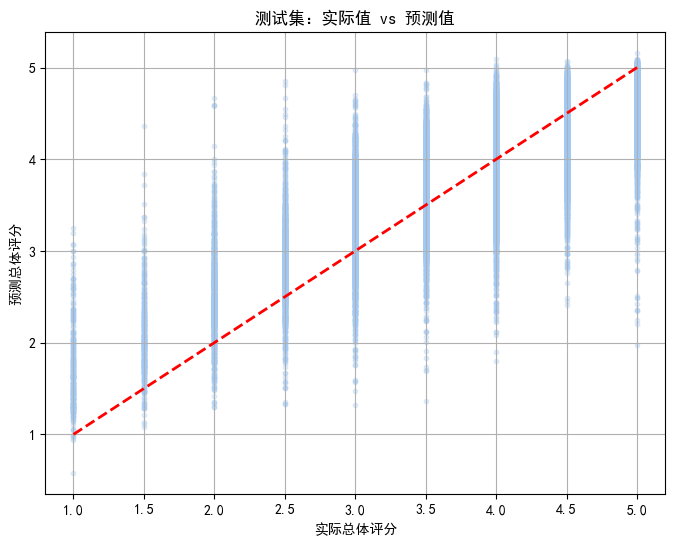

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('实际总体评分')
plt.ylabel('预测总体评分')
plt.title('测试集：实际值 vs 预测值')
plt.grid(True)
plt.show()

##### **从图中可以看到：**

点云整体沿着对角线分布，说明预测趋势与真实趋势一致。

在评分 3.0 ~ 4.5 这个区域（数据最密集的区域），点云最集中，预测效果最好。

#### **绘制：残差图 (检查误差是否均匀)**

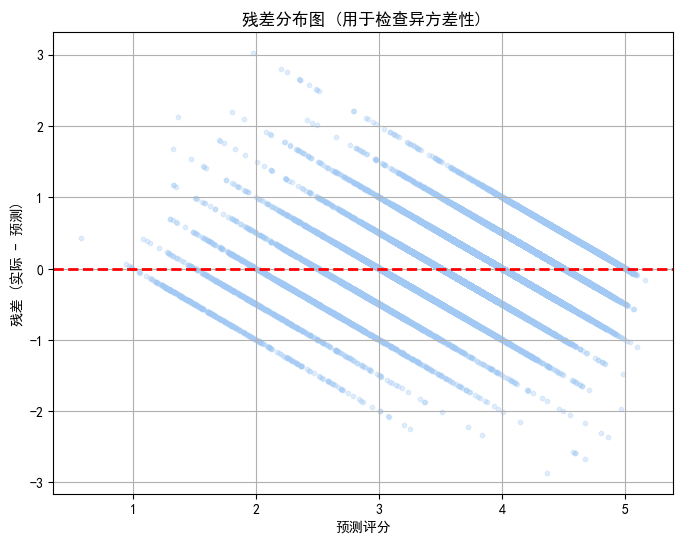

In [55]:
plt.rcParams['axes.unicode_minus'] = False
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('预测评分')
plt.ylabel('残差 (实际 - 预测)')
plt.title('残差分布图 (用于检查异方差性)')
plt.grid(True)
plt.show()

##### **图中可以看到：**

点围绕零线上下随机分布，没有明显的“喇叭口”或“曲线”形状，说明误差的方差大致恒定。

但是在预测评分 3.0 左右有一个轻微的“向下聚集”，在 4.5 以上有一些正残差和负残差的极端点，但整体来看不影响模型的可靠性。

#### **提取模型系数**

In [56]:
coefficients = final_model.params
print(coefficients)

const                0.522157
review_aroma         0.073536
review_appearance    0.052335
review_palate        0.267005
review_taste         0.554398
beer_abv            -0.040398
dtype: float64


##### **由此我们得出结论：**
口味（review_taste）权重最大（0.554）：口味评分每提高 1 分，总体评分平均提高 0.55 分。说明“好不好喝”是决定性的。

口感（review_palate）次之（0.267）：口感也很重要。

香气（0.073）和外观（0.052）影响较小：大家更关注喝进去的感觉，而不是闻起来或看起来。

酒精度（-0.040）是负相关：酒精度每高 1 度，评分平均下降 0.04 分。说明在这个数据集中，大家略微不喜欢高酒精度的啤酒。

### **模型评估总结**

综上，可以看出模型的预测效果很好，接下来就可以使用模型预测随机啤酒的总体评分了

### **建立随机啤酒评分数据，用模型来预测啤酒整体评分**

假设要某款啤酒的信息为香气4分，外观分3，口感分3.5，口味3分，酒精度7

In [57]:
predict_data = pd.DataFrame({'const':[1],'review_aroma':[4],'review_appearance':[3],
                             'review_palate':[3.5],'review_taste':[3],'beer_abv':[7]})
predict_data

,const,review_aroma,review_appearance,review_palate,review_taste,beer_abv
0,1,4,3,3.5,3,7


调用训练好的最终模型来预测结果

In [58]:
predicted_score = final_model.predict(predict_data)
predicted_score

0    3.288228
dtype: float64

##### **预测结果显示该啤酒的总体评分为3.28分**